## 개별 상권 리포트 

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)  # 모든 행 보이게

In [98]:
DF = pd.read_csv("export/final_merged_data.csv", encoding="utf-8")

In [99]:
# 코드 입력 함수
def create_df_by_code(code):
    """
    입력된 코드에 해당하는 열을 가진 df_code 데이터프레임을 생성합니다.
    
    Parameters:
    code (str): 코드
    
    Returns:
    pandas.DataFrame: 해당 코드의 데이터만 포함한 데이터프레임
    """
    # 코드에 해당하는 데이터만 필터링
    df_code = DF[DF['코드'] == code].copy()
    
    if df_code.empty:
        print(f"코드 '{code}'에 해당하는 데이터가 없습니다.")
        return None
    
    print(f"코드 '{code}'에 해당하는 데이터: {len(df_code)}개 행")
    return df_code


In [100]:
# 코드 입력하여 df_code 생성
code = "785B99118A"  # 여기에 원하는 상권 코드를 입력하세요
df_code = create_df_by_code(code)

# df_code가 생성되었는지 확인
if df_code is not None:
    print(f"\ndf_code 정보:")
    print(df_code.head())


코드 '785B99118A'에 해당하는 데이터: 24개 행

df_code 정보:
               코드                기준면적  가맹점명 브랜드코드      지역    상권       개설일  \
41613  785B99118A  서울특별시 성동구 장터길 44-2  오츠**   NaN  서울 성동구  금남시장  20210319   
41614  785B99118A  서울특별시 성동구 장터길 44-2  오츠**   NaN  서울 성동구  금남시장  20210319   
41615  785B99118A  서울특별시 성동구 장터길 44-2  오츠**   NaN  서울 성동구  금남시장  20210319   
41616  785B99118A  서울특별시 성동구 장터길 44-2  오츠**   NaN  서울 성동구  금남시장  20210319   
41617  785B99118A  서울특별시 성동구 장터길 44-2  오츠**   NaN  서울 성동구  금남시장  20210319   

       폐업일    기준년월  운영개월수  매출금액  매출건수  유니크고객수   객단가  취소율  배달매출비율  동종매출금액%  \
41613  NaN  202301   62.5  17.5  62.5    62.5   5.0  6.0    52.4    231.4   
41614  NaN  202302   62.5  17.5  62.5    62.5   5.0  1.0    40.7    248.5   
41615  NaN  202303   62.5  62.5  82.5    82.5  17.5  1.0    51.7     42.9   
41616  NaN  202304   62.5  37.5  62.5    62.5   5.0  1.0    56.3    174.0   
41617  NaN  202305   62.5  37.5  62.5    62.5   5.0  1.0    62.2    127.0   

       동종매출건수%  동종매출순위%  동일상

In [101]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 연령대별 컬럼명 정의
male_columns = ['남20대이하', '남30대', '남40대', '남50대', '남60대이상']
female_columns = ['여20대이하', '여30대', '여40대', '여50대', '여60대이상']
age_columns = ['20대이하', '30대', '40대', '50대', '60대이상']

print("연령대별 컬럼 설정 완료")


연령대별 컬럼 설정 완료


In [102]:
# 1. 남녀 비율 계산 함수
def calculate_gender_ratio(df):
    """남성 전체 vs 여성 전체 비율 계산"""
    male_total = df[male_columns].sum().sum()
    female_total = df[female_columns].sum().sum()
    
    total = male_total + female_total
    
    if total == 0:
        return 0, 0
    
    male_ratio = (male_total / total) * 100
    female_ratio = (female_total / total) * 100
    
    return male_ratio, female_ratio

# 2. 연령대별 비율 계산 함수 (남녀 합쳐서)
def calculate_age_ratio(df):
    """연령대별 비율 계산 (남녀 합쳐서)"""
    age_ratios = {}
    
    for i, age in enumerate(age_columns):
        male_col = male_columns[i]
        female_col = female_columns[i]
        
        age_total = df[male_col].sum() + df[female_col].sum()
        age_ratios[age] = age_total
    
    total = sum(age_ratios.values())
    
    if total == 0:
        return {age: 0 for age in age_columns}
    
    for age in age_ratios:
        age_ratios[age] = (age_ratios[age] / total) * 100
    
    return age_ratios

# 3. 남녀 연령대별 세분화 비율 계산 함수
def calculate_detailed_ratio(df):
    """남녀 연령대별 세분화 비율 계산"""
    detailed_ratios = {}
    
    for i, age in enumerate(age_columns):
        male_col = male_columns[i]
        female_col = female_columns[i]
        
        male_value = df[male_col].sum()
        female_value = df[female_col].sum()
        
        detailed_ratios[f"남{age}"] = male_value
        detailed_ratios[f"여{age}"] = female_value
    
    total = sum(detailed_ratios.values())
    
    if total == 0:
        return {key: 0 for key in detailed_ratios.keys()}
    
    for key in detailed_ratios:
        detailed_ratios[key] = (detailed_ratios[key] / total) * 100
    
    return detailed_ratios

print("비율 계산 함수 정의 완료")


비율 계산 함수 정의 완료


In [103]:
# 개별 원형 그래프 함수들은 통합 함수로 대체됨
print("원형 그래프 생성 함수 정의 완료")


원형 그래프 생성 함수 정의 완료


In [104]:
# 개별 세분화 원형 그래프 함수는 통합 함수로 대체됨
print("세분화 원형 그래프 생성 함수 정의 완료")


세분화 원형 그래프 생성 함수 정의 완료


코드 '785B99118A' 분석 결과
1. 남녀 비율
   남성: 54.3%
   여성: 45.7%

2. 연령대별 비율
   20대이하: 19.2%
   30대: 45.4%
   40대: 23.5%
   50대: 8.2%
   60대이상: 3.7%

3. 남녀 연령대별 세분화 비율
   남20대이하: 10.5%
   여20대이하: 8.8%
   남30대: 24.6%
   여30대: 20.7%
   남40대: 12.8%
   여40대: 10.8%
   남50대: 4.4%
   여50대: 3.7%
   남60대이상: 2.0%
   여60대이상: 1.7%

통합 원형 그래프 생성 중...
통합 원형 그래프가 저장되었습니다: export/zone_785B99118A_combined_pie_charts.png


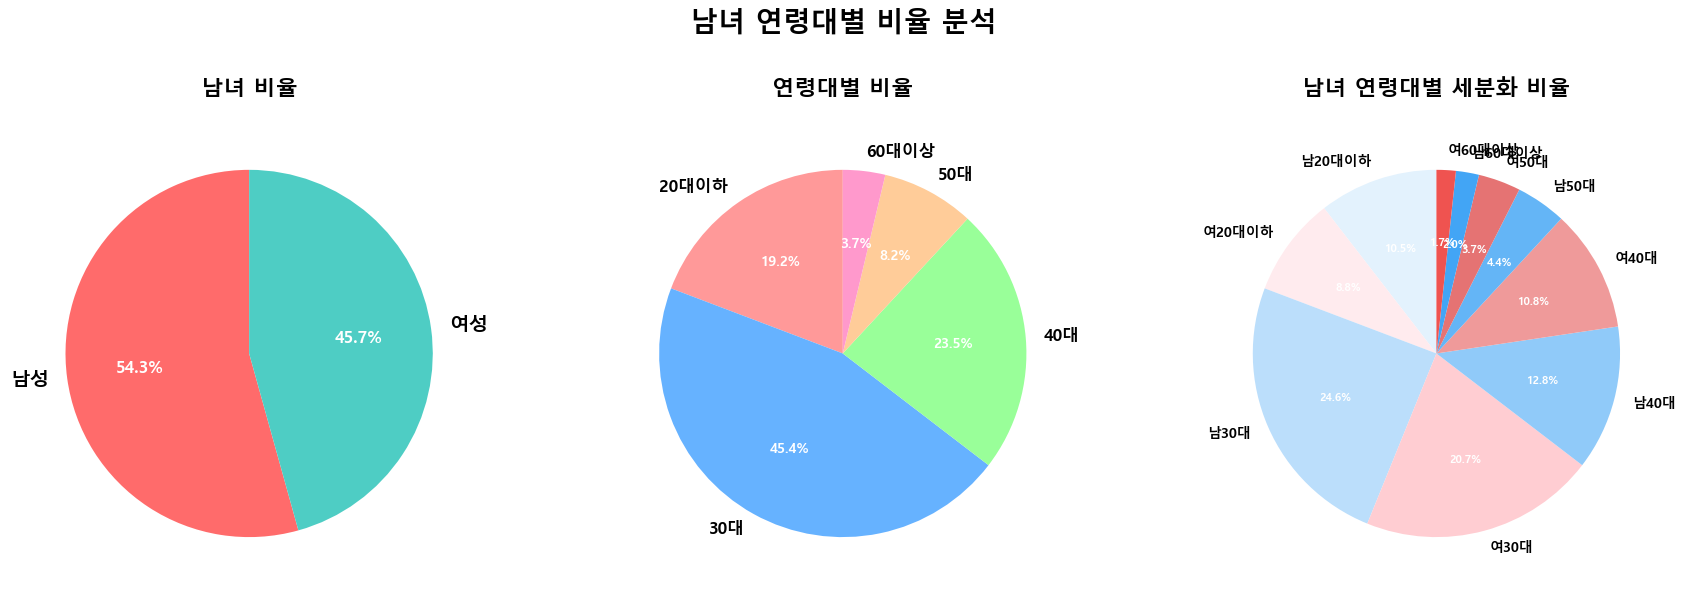


통합 원형 그래프가 'export/' 폴더에 저장되었습니다!
저장된 파일: zone_785B99118A_combined_pie_charts.png


In [108]:
# 3개 원형 그래프를 한 줄로 나란히 배치하는 함수
def create_combined_pie_charts(df, save_path=None):
    """3개 원형 그래프를 한 줄로 나란히 배치"""
    
    if df is None or df.empty:
        print("데이터가 없습니다.")
        return
    
    # 비율 계산
    male_ratio, female_ratio = calculate_gender_ratio(df)
    age_ratios = calculate_age_ratio(df)
    detailed_ratios = calculate_detailed_ratio(df)
    
    # 3개 서브플롯 생성 (1행 3열)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=False)
    fig.suptitle('남녀 연령대별 비율 분석', fontsize=20, fontweight='bold', y=0.98)
    
    # 1. 남녀 비율
    if male_ratio > 0 or female_ratio > 0:
        labels1 = ['남성', '여성']
        sizes1 = [male_ratio, female_ratio]
        colors1 = ['#FF6B6B', '#4ECDC4']
        
        wedges1, texts1, autotexts1 = axes[0].pie(sizes1, labels=labels1, colors=colors1,
                                                 autopct='%1.1f%%', shadow=False, startangle=90)
        
        for autotext in autotexts1:
            autotext.set_color('white')
            autotext.set_fontsize(12)
            autotext.set_weight('bold')
        
        for text in texts1:
            text.set_fontsize(14)
            text.set_weight('bold')
        
        axes[0].set_title('남녀 비율', fontsize=16, fontweight='bold', pad=20)
    
    # 2. 연령대별 비율
    if any(ratio > 0 for ratio in age_ratios.values()):
        labels2 = list(age_ratios.keys())
        sizes2 = list(age_ratios.values())
        colors2 = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
        
        wedges2, texts2, autotexts2 = axes[1].pie(sizes2, labels=labels2, colors=colors2,
                                                 autopct='%1.1f%%', shadow=False, startangle=90)
        
        for autotext in autotexts2:
            autotext.set_color('white')
            autotext.set_fontsize(10)
            autotext.set_weight('bold')
        
        for text in texts2:
            text.set_fontsize(12)
            text.set_weight('bold')
        
        axes[1].set_title('연령대별 비율', fontsize=16, fontweight='bold', pad=20)
    
    # 3. 세분화 비율
    if any(ratio > 0 for ratio in detailed_ratios.values()):
        labels3 = list(detailed_ratios.keys())
        sizes3 = list(detailed_ratios.values())
        
        # 남성은 파란색 계열, 여성은 빨간색 계열로 색상 설정
        colors3 = []
        for label in labels3:
            if '남' in label:
                if '20대이하' in label:
                    colors3.append('#E3F2FD')
                elif '30대' in label:
                    colors3.append('#BBDEFB')
                elif '40대' in label:
                    colors3.append('#90CAF9')
                elif '50대' in label:
                    colors3.append('#64B5F6')
                else:  # 60대이상
                    colors3.append('#42A5F5')
            else:  # 여성
                if '20대이하' in label:
                    colors3.append('#FFEBEE')
                elif '30대' in label:
                    colors3.append('#FFCDD2')
                elif '40대' in label:
                    colors3.append('#EF9A9A')
                elif '50대' in label:
                    colors3.append('#E57373')
                else:  # 60대이상
                    colors3.append('#EF5350')
        
        wedges3, texts3, autotexts3 = axes[2].pie(sizes3, labels=labels3, colors=colors3,
                                                 autopct='%1.1f%%', shadow=False, startangle=90)
        
        for autotext in autotexts3:
            autotext.set_color('white')
            autotext.set_fontsize(8)
            autotext.set_weight('bold')
        
        for text in texts3:
            text.set_fontsize(10)
            text.set_weight('bold')
        
        axes[2].set_title('남녀 연령대별 세분화 비율', fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"통합 원형 그래프가 저장되었습니다: {save_path}")
    
    plt.show()

# df_code에 대한 통합 원형 그래프 생성
if df_code is not None:
    print("=" * 50)
    print(f"코드 '{code}' 분석 결과")
    print("=" * 50)
    
    # 1. 남녀 비율
    male_ratio, female_ratio = calculate_gender_ratio(df_code)
    print(f"1. 남녀 비율")
    print(f"   남성: {male_ratio:.1f}%")
    print(f"   여성: {female_ratio:.1f}%")
    print()
    
    # 2. 연령대별 비율
    age_ratios = calculate_age_ratio(df_code)
    print(f"2. 연령대별 비율")
    for age, ratio in age_ratios.items():
        print(f"   {age}: {ratio:.1f}%")
    print()
    
    # 3. 세분화 비율
    detailed_ratios = calculate_detailed_ratio(df_code)
    print(f"3. 남녀 연령대별 세분화 비율")
    for key, ratio in detailed_ratios.items():
        print(f"   {key}: {ratio:.1f}%")
    
    print("\n" + "=" * 50)
    print("통합 원형 그래프 생성 중...")
    print("=" * 50)
    
    # 통합 원형 그래프 생성 및 저장
    create_combined_pie_charts(df_code, f'export/zone_{code}_combined_pie_charts.png')
    
    print(f"\n통합 원형 그래프가 'export/' 폴더에 저장되었습니다!")
    print(f"저장된 파일: zone_{code}_combined_pie_charts.png")
else:
    print("df_code가 생성되지 않았습니다. 코드를 확인해주세요.")


In [106]:
# 매출 관련 시계열 그래프 생성 함수
def create_sales_timeline_chart(df, save_path=None):
    """매출금액, 매출건수, 유니크고객수, 객단가 시계열 그래프 생성"""
    
    if df is None or df.empty:
        print("데이터가 없습니다.")
        return
    
    # 기준년월을 datetime으로 변환
    df_copy = df.copy()
    df_copy['기준년월'] = pd.to_datetime(df_copy['기준년월'], format='%Y%m')
    
    # 데이터 정렬 (시간순)
    df_copy = df_copy.sort_values('기준년월')
    
    # 그래프 생성
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('매출 관련 지표 시계열 분석', fontsize=20, fontweight='bold', y=0.98)
    
    # 1. 매출금액 (값은 그대로, Y축 스케일만 뒤집기)
    axes[0, 0].plot(df_copy['기준년월'], df_copy['매출금액'], marker='o', linewidth=2, markersize=6, color='#FF6B6B')
    axes[0, 0].set_title('매출금액 (상위 %)', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('상위 퍼센트 (%)', fontsize=12)
    axes[0, 0].set_ylim(100, 0)  # Y축 스케일 뒤집기 (위가 0%, 아래가 100%)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. 매출건수 (값은 그대로, Y축 스케일만 뒤집기)
    axes[0, 1].plot(df_copy['기준년월'], df_copy['매출건수'], marker='s', linewidth=2, markersize=6, color='#4ECDC4')
    axes[0, 1].set_title('매출건수 (상위 %)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('상위 퍼센트 (%)', fontsize=12)
    axes[0, 1].set_ylim(100, 0)  # Y축 스케일 뒤집기 (위가 0%, 아래가 100%)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. 유니크고객수 (값은 그대로, Y축 스케일만 뒤집기)
    axes[1, 0].plot(df_copy['기준년월'], df_copy['유니크고객수'], marker='^', linewidth=2, markersize=6, color='#45B7D1')
    axes[1, 0].set_title('유니크고객수 (상위 %)', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('상위 퍼센트 (%)', fontsize=12)
    axes[1, 0].set_ylim(100, 0)  # Y축 스케일 뒤집기 (위가 0%, 아래가 100%)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. 객단가 (값은 그대로, Y축 스케일만 뒤집기)
    axes[1, 1].plot(df_copy['기준년월'], df_copy['객단가'], marker='d', linewidth=2, markersize=6, color='#96CEB4')
    axes[1, 1].set_title('객단가 (상위 %)', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('상위 퍼센트 (%)', fontsize=12)
    axes[1, 1].set_ylim(100, 0)  # Y축 스케일 뒤집기 (위가 0%, 아래가 100%)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    # 모든 subplot에 x축 라벨 설정
    for ax in axes.flat:
        ax.set_xlabel('기준년월', fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"시계열 그래프가 저장되었습니다: {save_path}")
    
    plt.show()

print("시계열 그래프 생성 함수 정의 완료")


시계열 그래프 생성 함수 정의 완료


코드 '785B99118A' 매출 시계열 분석
시계열 그래프가 저장되었습니다: export/zone_785B99118A_sales_timeline.png


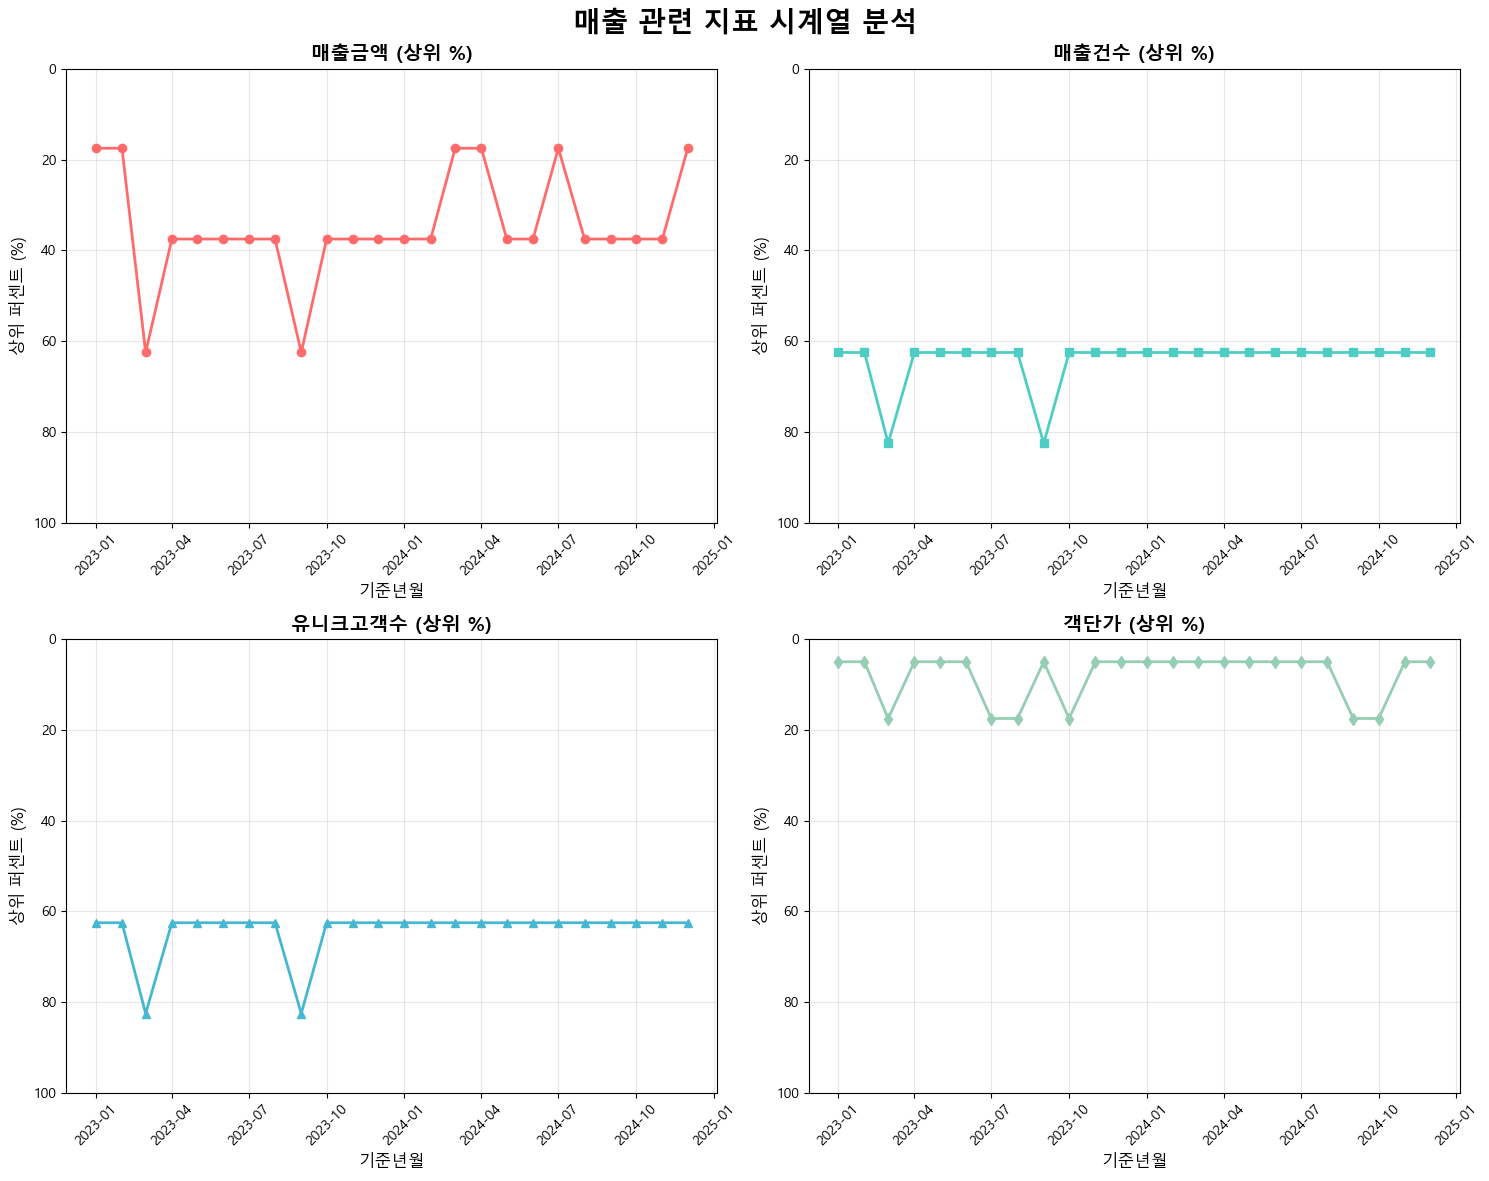


시계열 그래프가 'export/' 폴더에 저장되었습니다!
저장된 파일: zone_785B99118A_sales_timeline.png


In [107]:
# df_code에 대한 시계열 그래프 생성
if df_code is not None:
    print("=" * 50)
    print(f"코드 '{code}' 매출 시계열 분석")
    print("=" * 50)
    
    # 시계열 그래프 생성 및 저장
    create_sales_timeline_chart(df_code, f'export/zone_{code}_sales_timeline.png')
    
    print(f"\n시계열 그래프가 'export/' 폴더에 저장되었습니다!")
    print(f"저장된 파일: zone_{code}_sales_timeline.png")
else:
    print("df_code가 생성되지 않았습니다. 코드를 확인해주세요.")
